# Import libraries and generate data

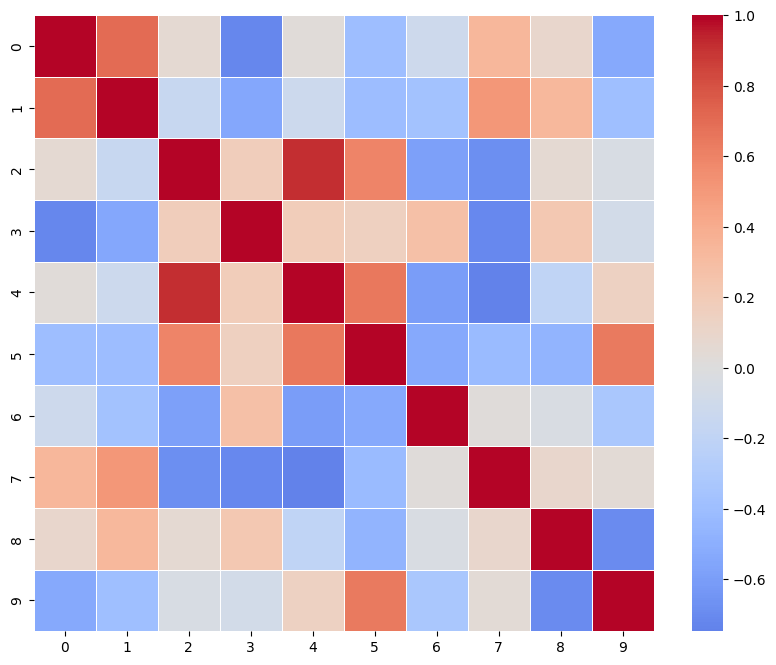

In [351]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)
n, p = 100, 10  

mean = np.random.uniform(-5, 5, size=p)
A = np.random.uniform(-0.7, 0.7, size=(p, p))
corr_matrix = (A + A.T)/2
np.fill_diagonal(corr_matrix, 1.0)
cov_matrix = np.dot(corr_matrix, corr_matrix.T)

cor_matrix =pd.DataFrame(cov_matrix).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(cor_matrix,
            annot=False,        # show correlation values
            cmap="coolwarm",   # color palette
            center=0,          # center colormap at zero
            linewidths=0.5)    # grid lines between cells
plt.show()

X = np.random.multivariate_normal(mean, cov_matrix, size=n)
true_beta = np.array([1.5, 0, -2.0, 0, 0.5, 0, 0, -1.2, 0, 3])
noise = np.random.normal(0, 1, n)

y = X @ true_beta + 0.5*noise


In [347]:
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV


df_coef=pd.DataFrame(true_beta,columns=["True Beta"])
df_param=pd.DataFrame(["intercept","lambda 1","lambda 2"])

lambda_1=2.5
lambda_2=2.5

# Fit using `sklearn`

In [348]:
#Elastic net
elastic_pipeline = make_pipeline(StandardScaler(), ElasticNet(alpha=(lambda_1+lambda_2)/n,l1_ratio=lambda_1/(lambda_1+lambda_2), fit_intercept=True,random_state=42))
elastic_pipeline.fit(X, y.ravel())
elastic_model = elastic_pipeline.named_steps['elasticnet']
df_param["Elastic Net"]=[elastic_model.intercept_,lambda_1,lambda_2]
df_coef["Elastic net"] = elastic_model.coef_

In [349]:
# Lasso
lasso_pipeline = make_pipeline(StandardScaler(), Lasso(alpha=lambda_1/n, fit_intercept=True,random_state=42))
lasso_pipeline.fit(X, y.ravel())
lasso_model = lasso_pipeline.named_steps['lasso']
df_param["Lasso"]=[lasso_model.intercept_,lambda_1,0]
df_coef["Lasso"] =lasso_model.coef_


In [350]:
print("======= Estimated parameters =======")
print(df_coef)
print("")
print(df_param)

======= Estimated parameters =======
   True Beta  Elastic net     Lasso
0        1.5     1.141163  2.056200
1        0.0    -0.390317 -0.138376
2       -2.0    -3.088744 -2.956827
3        0.0    -0.326179 -0.000000
4        0.5     1.154781  0.727320
5        0.0    -0.171585 -0.010947
6        0.0    -0.439827 -0.000000
7       -1.2    -0.971009 -1.422354
8        0.0    -0.643330 -0.009166
9        3.0     2.707942  3.908690

           0  Elastic Net     Lasso
0  intercept    -6.555659 -6.555659
1   lambda 1     2.500000  2.500000
2   lambda 2     2.500000  0.000000


ElasticNet and Lasso from `sklearn` produces similar results.  Lasso generally obtained smaller estimates that are closer to the true regression coefficiets, except for $\beta_0,\beta_7$ and $\beta_9$. The Lasso solution is more sparse but by including the L2 prenalty, elastic net improves stability by shrinking coefficients of noisy and correlated predictors.

# Fit with coordinate descent

In [334]:
df_coef=pd.DataFrame(true_beta,columns=["True Beta"])
df_param=pd.DataFrame(["intercept","lambda 1","lambda 2"])

In [ ]:
def soft_thresholding(x, lambda_):
    if x > 0 and lambda_ < np.abs(x):
        return x - lambda_
    elif x < 0 and lambda_ < np.abs(x):
        return x + lambda_
    else:
        return 0
    

def coordinate_descent_elasticnet_with_intercept_with_history(X, y, lambda_1, lambda_2, num_iterations=1000, tol=1e-6):
    n, p = X.shape
    # Standardize X and center y
    X_mean = np.mean(X, axis=0)
    X_std = np.std(X, axis=0, ddof=0)
    y_mean = np.mean(y)
    
    X_std[X_std == 0] = 1  # To avoid division by zero for constant columns
    X_scaled = (X - X_mean) / X_std
    y_centered = y - y_mean

    beta = np.zeros(p)
    beta_hist = np.zeros(shape = (1, p))
    beta_hist_all = np.zeros(shape=(1,p))
    for iteration in range(num_iterations):
        beta_old = beta.copy()
        for j in range(p):
            residual = y_centered - X_scaled @ beta + beta[j] * X_scaled[:, j]
            rho = X_scaled[:, j].T @ residual
            #beta[j] = soft_thresholding(rho / ((X_scaled[:, j].T @ X_scaled[:, j])+lambda_2), lambda_1)
            beta[j] = soft_thresholding(rho , lambda_1)/((X_scaled[:, j].T @ X_scaled[:, j])+lambda_2)
            beta_hist_all = np.concatenate((beta_hist_all, beta.reshape(1,-1)), axis=0)
        # Check for convergence (change in coefficients)
        beta_hist = np.concatenate((beta_hist, beta.reshape(1,-1)), axis=0)
        if np.linalg.norm(beta - beta_old, ord=2) < tol:
            print(f"Converged after {iteration + 1} iterations")
            break

    # Compute the intercept using the non-centered response
    intercept = y_mean - np.mean(X, axis=0) @ beta
    return intercept, beta, beta_hist, beta_hist_all



In [337]:
intercept, beta_estimated, beta_hist, beta_hist_all = coordinate_descent_elasticnet_with_intercept_with_history(X, y.ravel(), lambda_1,lambda_2)
df_param["Elastic Net"]=[intercept,lambda_1,lambda_2]
df_coef["Elastic Net"] =beta_estimated

Converged after 224 iterations


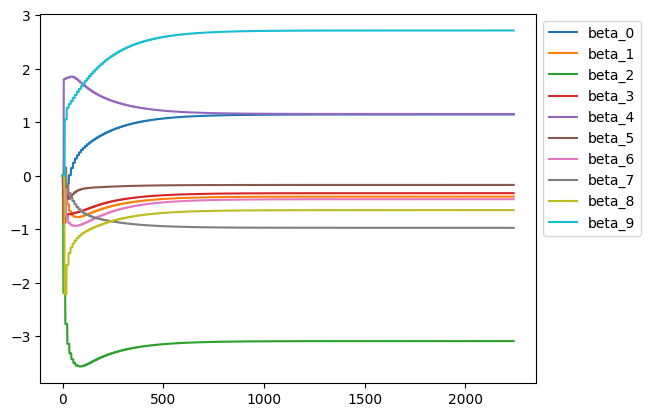

In [338]:
plt.figure()
for i in range(beta_hist_all.shape[1]):
    all_beta_i = beta_hist_all[:,i]
    plt.plot(all_beta_i, label = f'beta_{i}')
plt.legend(bbox_to_anchor = (1,1))
plt.show()

In [339]:

def coordinate_descent_lasso_with_intercept_with_history(X, y, lambda_1, num_iterations=1000, tol=1e-6):
    n, p = X.shape
    # Standardize X and center y
    X_mean = np.mean(X, axis=0)
    X_std = np.std(X, axis=0, ddof=0)
    y_mean = np.mean(y)
    
    X_std[X_std == 0] = 1  # To avoid division by zero for constant columns
    X_scaled = (X - X_mean) / X_std
    y_centered = y - y_mean

    beta = np.zeros(p)
    beta_hist = np.zeros(shape = (1, p))
    beta_hist_all = np.zeros(shape=(1,p))
    for iteration in range(num_iterations):
        beta_old = beta.copy()
        for j in range(p):
            residual = y_centered - X_scaled @ beta + beta[j] * X_scaled[:, j]
            rho = X_scaled[:, j].T @ residual
            beta[j] = soft_thresholding(rho , lambda_1)/ (X_scaled[:, j].T @ X_scaled[:, j])
            beta_hist_all = np.concatenate((beta_hist_all, beta.reshape(1,-1)), axis=0)
        # Check for convergence (change in coefficients)
        beta_hist = np.concatenate((beta_hist, beta.reshape(1,-1)), axis=0)
        if np.linalg.norm(beta - beta_old, ord=2) < tol:
            print(f"Converged after {iteration + 1} iterations")
            break

    # Compute the intercept using the non-centered response
    intercept = y_mean - np.mean(X, axis=0) @ beta
    return intercept, beta, beta_hist, beta_hist_all

In [340]:
# Run the coordinate descent algorithm 
intercept, beta_estimated, beta_hist, beta_hist_all = coordinate_descent_lasso_with_intercept_with_history(X, y.ravel(), lambda_1)
df_param["Lasso"]=[intercept,lambda_1,0]
df_coef["Lasso"] =beta_estimated

Converged after 227 iterations


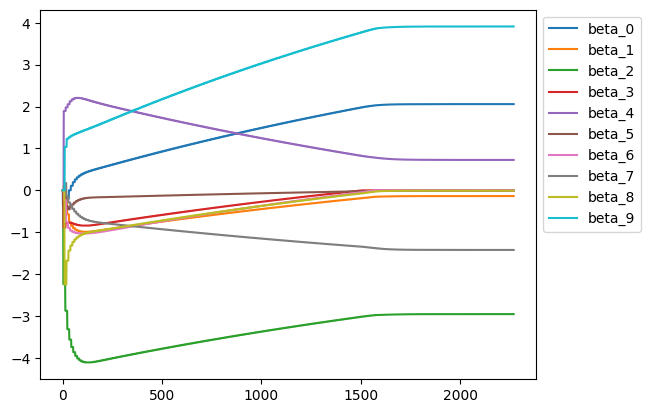

In [341]:
plt.figure()
for i in range(beta_hist_all.shape[1]):
    all_beta_i = beta_hist_all[:,i]
    plt.plot(all_beta_i, label = f'beta_{i}')
plt.legend(bbox_to_anchor = (1,1))
plt.show()

In [342]:
print("======= Estimated parameters =======")
print(df_coef)
print("")
print(df_param)

======= Estimated parameters =======
   True Beta  Elastic Net     Lasso
0        1.5     1.143759  2.057208
1        0.0    -0.388759 -0.137503
2       -2.0    -3.086757 -2.955319
3        0.0    -0.324839  0.000000
4        0.5     1.152650  0.724838
5        0.0    -0.171313 -0.011044
6        0.0    -0.437841  0.000000
7       -1.2    -0.972034 -1.423903
8        0.0    -0.641591 -0.008706
9        3.0     2.711970  3.910474

           0  Elastic Net     Lasso
0  intercept     4.495029  3.440715
1   lambda 1     2.500000  2.500000
2   lambda 2     2.500000  0.000000


Coordinet descent and `sklearn` obtained almost identical estimates with most variation only present in the lower desimal values. The same pattern as before is therefore observed from the final estimates as well as the plots that lasso produces a more sparce solution, while elastic net a more stable solution.  The most notable difference is the estimated intercept. With `sklearn` the estimated intercept was -6.555659 for both lasso and elastic net, while coordinet decent obtained different positive estimates for the regression models. As expected, elastic net converged faster than lasso.